In [16]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/icml_face_data.csv
/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/fer2013.tar.gz
/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/example_submission.csv
/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/train.csv
/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/test.csv


In [17]:
!pip install wandb -q

In [18]:
import wandb

wandb.login(relogin=True)

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tarfile
import copy                                  
import torch
import torch.nn as nn
import torch.nn.functional as F             
import torch.optim as optim                  
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import torchvision.models as models          
from sklearn.model_selection import train_test_split  
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay  

from PIL import Image                       

import warnings
warnings.filterwarnings('ignore')

emotion_labels = {
    0: 'Angry', 1: 'Disgust', 2: 'Fear',
    3: 'Happy', 4: 'Sad', 5: 'Surprise', 6: 'Neutral'
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("All imports successful")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device:", device)

All imports successful
PyTorch version: 2.10.0+cu128
CUDA available: True
Device: cuda


In [20]:
train_df = pd.read_csv('/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/train.csv')
test_df  = pd.read_csv('/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/test.csv')

print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)
print("\nTrain columns:", train_df.columns.tolist())
print("Test columns: ", test_df.columns.tolist())
print("\nFirst row emotion:", train_df['emotion'].iloc[0])
print("First row pixel count:", len(train_df['pixels'].iloc[0].split()))

Train shape: (28709, 2)
Test shape:  (7178, 1)

Train columns: ['emotion', 'pixels']
Test columns:  ['pixels']

First row emotion: 0
First row pixel count: 2304


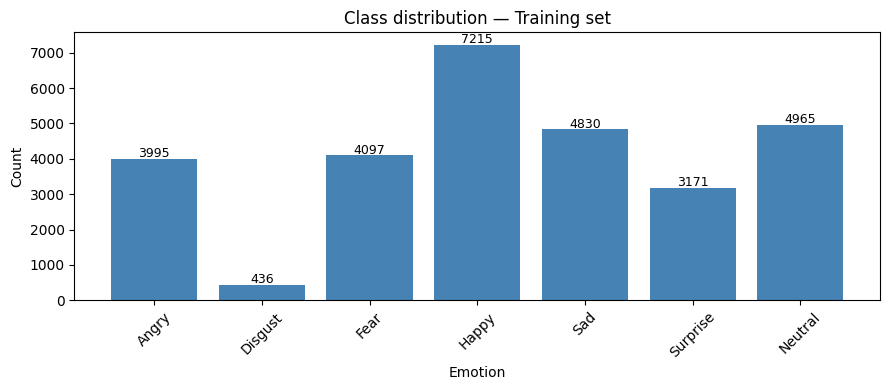

Largest class:   7215 (Happy)
Smallest class:  436 (Disgust)
Imbalance ratio: 16.5x


In [21]:
fig, ax = plt.subplots(figsize=(9, 4))

counts = train_df['emotion'].value_counts().sort_index()
bars = ax.bar([emotion_labels[i] for i in counts.index], counts.values, color='steelblue')
ax.set_title('Class distribution — Training set')
ax.set_xlabel('Emotion')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)

for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 50, str(val), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"Largest class:   {counts.max()} ({emotion_labels[counts.idxmax()]})")
print(f"Smallest class:  {counts.min()} ({emotion_labels[counts.idxmin()]})")
print(f"Imbalance ratio: {counts.max() / counts.min():.1f}x")

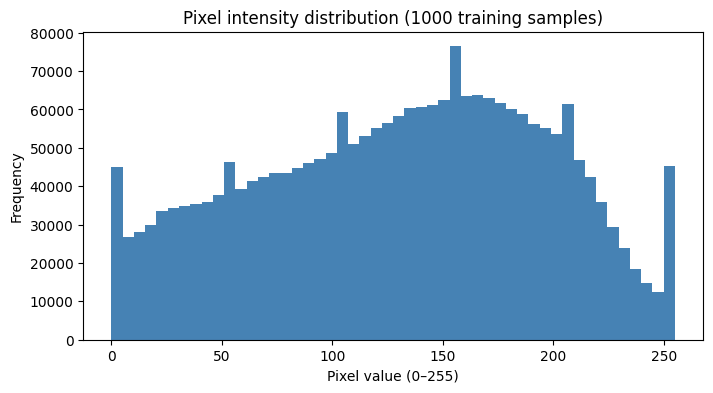

Raw mean: 130.09  →  normalized mean: 0.5101
Raw std:  65.29   →  normalized std:  0.2560

(We'll use these values in the normalization transform)


In [22]:
sample = train_df.sample(1000, random_state=42)
all_pixels = []

for _, row in sample.iterrows():
    pixels = np.array(row['pixels'].split(), dtype=np.uint8)
    all_pixels.extend(pixels.tolist())

all_pixels = np.array(all_pixels)

plt.figure(figsize=(8, 4))
plt.hist(all_pixels, bins=50, color='steelblue', edgecolor='none')
plt.title('Pixel intensity distribution (1000 training samples)')
plt.xlabel('Pixel value (0–255)')
plt.ylabel('Frequency')
plt.show()

PIXEL_MEAN = all_pixels.mean() / 255.0
PIXEL_STD  = all_pixels.std()  / 255.0

print(f"Raw mean: {all_pixels.mean():.2f}  →  normalized mean: {PIXEL_MEAN:.4f}")
print(f"Raw std:  {all_pixels.std():.2f}   →  normalized std:  {PIXEL_STD:.4f}")
print("\n(We'll use these values in the normalization transform)")

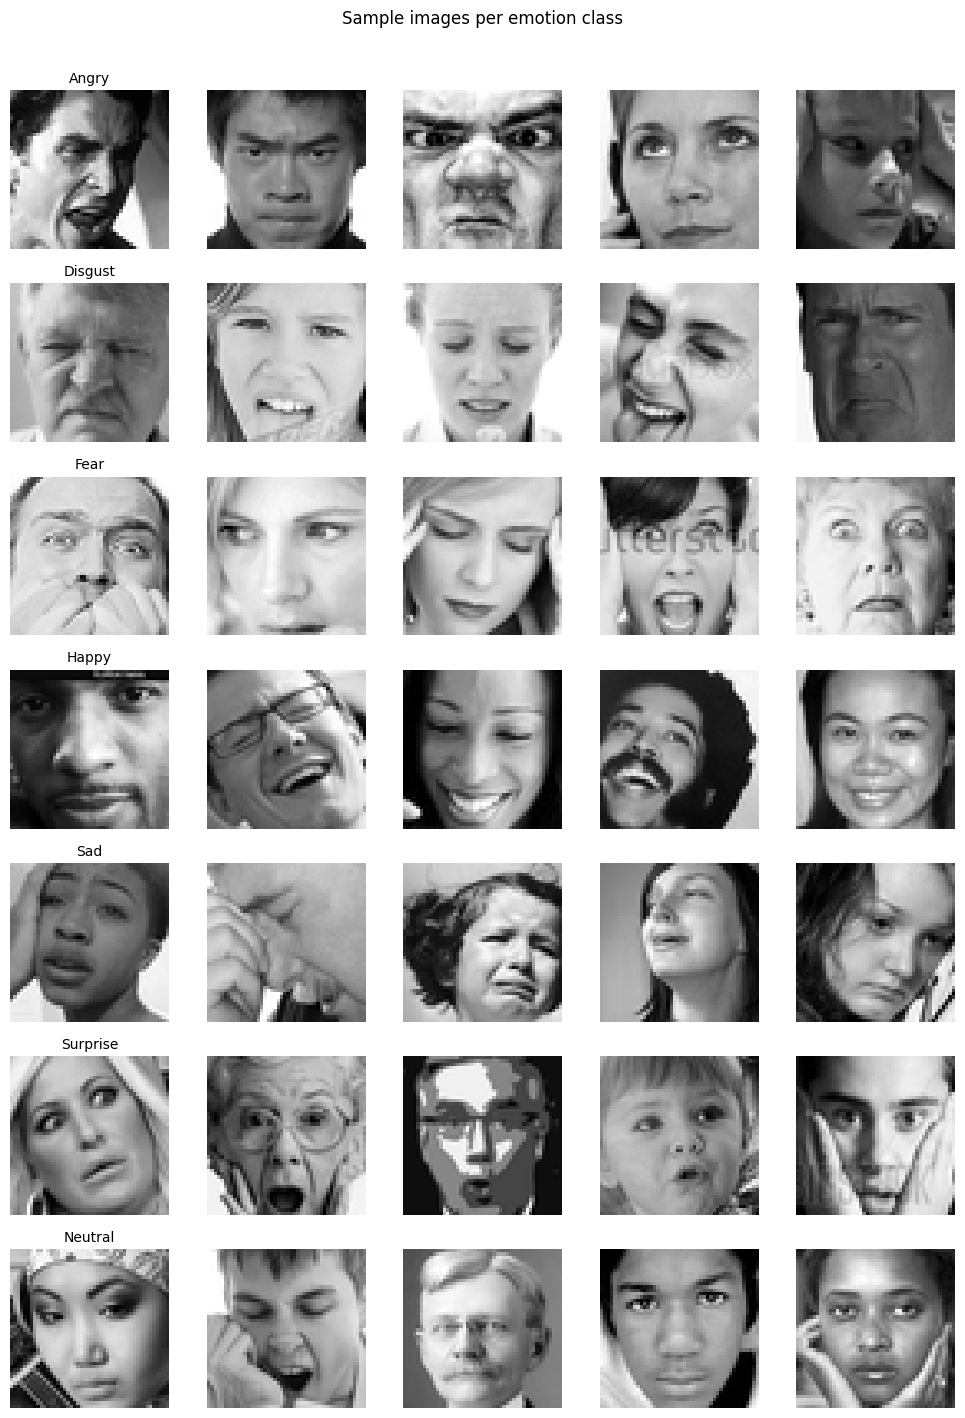

In [23]:
fig, axes = plt.subplots(7, 5, figsize=(10, 14))

for emotion_id in range(7):
    samples = train_df[train_df['emotion'] == emotion_id].sample(5, random_state=42)
    for col, (_, row) in enumerate(samples.iterrows()):
        pixels = np.array(row['pixels'].split(), dtype=np.uint8).reshape(48, 48)
        axes[emotion_id][col].imshow(pixels, cmap='gray')
        axes[emotion_id][col].axis('off')
        if col == 0:
            axes[emotion_id][col].set_title(emotion_labels[emotion_id], fontsize=10)

plt.suptitle('Sample images per emotion class', y=1.01)
plt.tight_layout()
plt.show()

In [24]:
# Missing values
print("=== Missing Values ===")
print("Train:\n", train_df.isnull().sum())
print("\nTest:\n",  test_df.isnull().sum())

# Duplicates
dupes = train_df.duplicated(subset='pixels').sum()
print(f"\n=== Duplicates ===")
print(f"Duplicate images in train: {dupes}")

# Pixel vector length
lengths = train_df['pixels'].apply(lambda x: len(x.split()))
print(f"\n=== Pixel Vector Lengths ===")
print(f"Min: {lengths.min()}, Max: {lengths.max()}, Expected: 2304 (48×48)")
print(f"All correct: {(lengths == 2304).all()}")

# Per-class counts as a clean table
print(f"\n=== Per-class counts ===")
for i, count in counts.items():
    pct = count / len(train_df) * 100
    print(f"  {emotion_labels[i]:<10} {count:>5}  ({pct:.1f}%)")

=== Missing Values ===
Train:
 emotion    0
pixels     0
dtype: int64

Test:
 pixels    0
dtype: int64

=== Duplicates ===
Duplicate images in train: 1236

=== Pixel Vector Lengths ===
Min: 2304, Max: 2304, Expected: 2304 (48×48)
All correct: True

=== Per-class counts ===
  Angry       3995  (13.9%)
  Disgust      436  (1.5%)
  Fear        4097  (14.3%)
  Happy       7215  (25.1%)
  Sad         4830  (16.8%)
  Surprise    3171  (11.0%)
  Neutral     4965  (17.3%)


In [25]:
from torch import tensor

class_counts = torch.tensor(
    [counts[i] for i in range(7)], dtype=torch.float
)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * 7  # normalize to sum to num_classes

print("Class weights (higher = model penalized more for missing that class):")
for i, w in enumerate(class_weights):
    print(f"  {emotion_labels[i]:<10} weight: {w:.4f}")

Class weights (higher = model penalized more for missing that class):
  Angry      weight: 0.4800
  Disgust    weight: 4.3982
  Fear       weight: 0.4681
  Happy      weight: 0.2658
  Sad        weight: 0.3970
  Surprise   weight: 0.6047
  Neutral    weight: 0.3862


In [26]:
print(f"Before dedup: {len(train_df)}")
train_df = train_df.drop_duplicates(subset='pixels').reset_index(drop=True)
print(f"After dedup:  {len(train_df)}")

# Verify class distribution after dedup
counts = train_df['emotion'].value_counts().sort_index()
print("\nClass counts after dedup:")
for i, count in counts.items():
    pct = count / len(train_df) * 100
    print(f"  {emotion_labels[i]:<10} {count:>5}  ({pct:.1f}%)")

Before dedup: 28709
After dedup:  27473

Class counts after dedup:
  Angry       3840  (14.0%)
  Disgust      381  (1.4%)
  Fear        3897  (14.2%)
  Happy       7086  (25.8%)
  Sad         4724  (17.2%)
  Surprise    2675  (9.7%)
  Neutral     4870  (17.7%)


In [27]:
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df['emotion']  # preserve class distribution in both splits
)

train_data = train_data.reset_index(drop=True)
val_data   = val_data.reset_index(drop=True)

print(f"Train size: {len(train_data)}")
print(f"Val size:   {len(val_data)}")

# Confirm stratification worked
print("\nTrain class distribution:")
for i, count in train_data['emotion'].value_counts().sort_index().items():
    print(f"  {emotion_labels[i]:<10} {count:>5}  ({count/len(train_data)*100:.1f}%)")

print("\nVal class distribution:")
for i, count in val_data['emotion'].value_counts().sort_index().items():
    print(f"  {emotion_labels[i]:<10} {count:>5}  ({count/len(val_data)*100:.1f}%)")

Train size: 21978
Val size:   5495

Train class distribution:
  Angry       3072  (14.0%)
  Disgust      305  (1.4%)
  Fear        3117  (14.2%)
  Happy       5669  (25.8%)
  Sad         3779  (17.2%)
  Surprise    2140  (9.7%)
  Neutral     3896  (17.7%)

Val class distribution:
  Angry        768  (14.0%)
  Disgust       76  (1.4%)
  Fear         780  (14.2%)
  Happy       1417  (25.8%)
  Sad          945  (17.2%)
  Surprise     535  (9.7%)
  Neutral      974  (17.7%)


In [28]:
class_counts = torch.tensor(
    [train_data['emotion'].value_counts().sort_index()[i] for i in range(7)],
    dtype=torch.float
)
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * 7

print("Updated class weights:")
for i, w in enumerate(class_weights):
    print(f"  {emotion_labels[i]:<10} weight: {w:.4f}")

Updated class weights:
  Angry      weight: 0.4477
  Disgust    weight: 4.5090
  Fear       weight: 0.4412
  Happy      weight: 0.2426
  Sad        weight: 0.3639
  Surprise   weight: 0.6426
  Neutral    weight: 0.3530


In [29]:
from PIL import Image
from torch.utils.data import Dataset

class FERDataset(Dataset):
    def __init__(self, dataframe, transform=None, has_labels=True):
        self.data = dataframe.reset_index(drop=True)
        self.transform = transform
        self.has_labels = has_labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        # Parse pixel string → 48x48 numpy array → PIL Image
        pixels = np.array(row['pixels'].split(), dtype=np.uint8).reshape(48, 48)
        image = Image.fromarray(pixels)

        if self.transform:
            image = self.transform(image)

        if self.has_labels:
            label = torch.tensor(row['emotion'], dtype=torch.long)
            return image, label
        return image

print("FERDataset class defined")

FERDataset class defined


In [30]:
# Use the mean/std we computed from EDA
PIXEL_MEAN = 0.5077  # replace with your actual printed value from Cell 5
PIXEL_STD  = 0.2550  # replace with your actual printed value from Cell 5

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.RandomCrop(48, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[PIXEL_MEAN], std=[PIXEL_STD])
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[PIXEL_MEAN], std=[PIXEL_STD])
])

print("Transforms defined")
print(f"Using normalization — mean: {PIXEL_MEAN}, std: {PIXEL_STD}")

Transforms defined
Using normalization — mean: 0.5077, std: 0.255


In [31]:
BATCH_SIZE = 64

train_dataset = FERDataset(train_data, transform=train_transform, has_labels=True)
val_dataset   = FERDataset(val_data,   transform=eval_transform,  has_labels=True)
test_dataset  = FERDataset(test_df,    transform=eval_transform,  has_labels=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

# Sanity check
images, labels = next(iter(train_loader))
print(f"Batch shape:  {images.shape}")    # [64, 1, 48, 48]
print(f"Labels shape: {labels.shape}")    # [64]
print(f"Pixel range:  {images.min():.3f} to {images.max():.3f}")
print(f"Label range:  {labels.min()} to {labels.max()}")
print(f"\nTrain batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Batch shape:  torch.Size([64, 1, 48, 48])
Labels shape: torch.Size([64])
Pixel range:  -1.991 to 1.931
Label range:  0 to 6

Train batches: 344
Val batches:   86
Test batches:  113


In [17]:
import torch.nn as nn
import torch.nn.functional as F

class TinyCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(TinyCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)  # 48x48 → 48x48
        self.pool  = nn.MaxPool2d(2, 2)                           # 48x48 → 24x24
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1) # 24x24 → 24x24
                                                                   # pool → 12x12
        self.fc1   = nn.Linear(32 * 12 * 12, 128)
        self.fc2   = nn.Linear(128, num_classes)
        self.drop  = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # conv → relu → pool
        x = self.pool(F.relu(self.conv2(x)))  # conv → relu → pool
        x = x.view(x.size(0), -1)             # flatten
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        x = self.fc2(x)
        return x

device = torch.device('cpu')
model  = TinyCNN(num_classes=7).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: TinyCNN")
print(f"Parameters: {total_params:,}")

# Forward pass check
dummy = torch.zeros(1, 1, 48, 48)
print(f"Output shape: {model(dummy).shape}")  # should be [1, 7]

Model: TinyCNN
Parameters: 595,655
Output shape: torch.Size([1, 7])


In [20]:
import torch.optim as optim
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print("Ready to train")

Ready to train


In [21]:
wandb.init(
    project="fer2013-experiments",
    name="exp1-tinycnn",
    config={
        "model": "TinyCNN",
        "epochs": 5,
        "batch_size": BATCH_SIZE,
        "optimizer": "Adam",
        "learning_rate": 1e-3,
        "class_weights": True,
        "device": str(device),
    }
)
print("WandB run started:", wandb.run.name)

WandB run started: exp1-tinycnn


In [22]:
NUM_EPOCHS = 5

for epoch in range(1, NUM_EPOCHS + 1):
    # Train
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item() * images.size(0)
        _, predicted   = outputs.max(1)
        train_correct += predicted.eq(labels).sum().item()
        train_total   += labels.size(0)

    # Validate
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss    += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            val_correct += predicted.eq(labels).sum().item()
            val_total   += labels.size(0)

    train_loss_avg = train_loss / train_total
    train_acc      = train_correct / train_total
    val_loss_avg   = val_loss / val_total
    val_acc        = val_correct / val_total

    wandb.log({
        "epoch":      epoch,
        "train_loss": train_loss_avg,
        "train_acc":  train_acc,
        "val_loss":   val_loss_avg,
        "val_acc":    val_acc,
    })

    print(f"Epoch {epoch}/{NUM_EPOCHS} | "
          f"Train loss: {train_loss_avg:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss_avg:.4f} acc: {val_acc:.4f}")

wandb.finish()

Epoch 1/5 | Train loss: 1.9234 acc: 0.1922 | Val loss: 1.8446 acc: 0.2777
Epoch 2/5 | Train loss: 1.8476 acc: 0.2730 | Val loss: 1.7431 acc: 0.3478
Epoch 3/5 | Train loss: 1.7907 acc: 0.3054 | Val loss: 1.6534 acc: 0.3780
Epoch 4/5 | Train loss: 1.7477 acc: 0.3204 | Val loss: 1.6055 acc: 0.4124
Epoch 5/5 | Train loss: 1.7083 acc: 0.3351 | Val loss: 1.5741 acc: 0.4102


epoch,▁▃▅▆█
train_acc,▁▅▇▇█
train_loss,█▆▄▂▁
val_acc,▁▅▆██
val_loss,█▅▃▂▁
epoch,5
train_acc,0.33506
train_loss,1.7083
val_acc,0.41019
val_loss,1.57413


# EARLY STOPPING CLASS

In [32]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.001, verbose=True):
        """
        patience  : how many epochs to wait after last improvement
        min_delta : minimum change to count as improvement
        verbose   : print message when stopping
        """
        self.patience   = patience
        self.min_delta  = min_delta
        self.verbose    = verbose
        self.counter    = 0
        self.best_score = None
        self.stopped    = False
        self.best_epoch = 0

    def step(self, val_loss, epoch):
        score = -val_loss  # higher is better

        if self.best_score is None:
            self.best_score = score
            self.best_epoch = epoch

        elif score < self.best_score + self.min_delta:
            self.counter += 1
            if self.verbose:
                print(f"  EarlyStopping: no improvement for {self.counter}/{self.patience} epochs")
            if self.counter >= self.patience:
                self.stopped = True

        else:
            self.best_score = score
            self.best_epoch = epoch
            self.counter    = 0

    def should_stop(self):
        return self.stopped


print("EarlyStopping class defined")
print("patience=7 means training stops if val_loss doesn't improve for 7 epochs")

EarlyStopping class defined
patience=7 means training stops if val_loss doesn't improve for 7 epochs


# DEEP CNN WITHOUT BATCHNORM

In [35]:
class DeepCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(DeepCNN, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 3 * 3, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.classifier(x)
        return x

In [37]:
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = DeepCNN(num_classes=7).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
early_stopping = EarlyStopping(patience=7, min_delta=0.001, verbose=True)
NUM_EPOCHS = 30

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: DeepCNN | Params: {total_params:,} | Device: {device}")

# --- wandb ---
wandb.init(
    project="fer2013-experiments",
    name="exp2-deepcnn",
    config={
        "model": "DeepCNN",
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "optimizer": "Adam",
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "scheduler": "ReduceLROnPlateau",
        "batchnorm": False,
        "dropout": 0.5,
        "class_weights": True,
        "device": str(device),
    }
)

best_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    # train
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item() * images.size(0)
        _, pred        = model(images).max(1)
        train_correct += pred.eq(labels).sum().item()
        train_total   += labels.size(0)

    # validate
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            out  = model(images)
            loss = criterion(out, labels)
            val_loss    += loss.item() * images.size(0)
            _, pred      = out.max(1)
            val_correct += pred.eq(labels).sum().item()
            val_total   += labels.size(0)

    train_loss_avg = train_loss / train_total
    train_acc      = train_correct / train_total
    val_loss_avg   = val_loss / val_total
    val_acc        = val_correct / val_total
    current_lr     = optimizer.param_groups[0]['lr']

    scheduler.step(val_loss_avg)
    early_stopping.step(val_loss_avg, epoch)

    wandb.log({
        "epoch":      epoch,
        "train_loss": train_loss_avg,
        "train_acc":  train_acc,
        "val_loss":   val_loss_avg,
        "val_acc":    val_acc,
        "lr":         current_lr,
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_deepcnn.pth')
        marker = "  ← best"
    else:
        marker = ""

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train loss: {train_loss_avg:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss_avg:.4f} acc: {val_acc:.4f} | "
          f"LR: {current_lr:.6f}{marker}")

    if early_stopping.should_stop():           # ← check and break
        print(f"\nEarly stopping at epoch {epoch}")
        print(f"Best epoch: {early_stopping.best_epoch}")
        break

print(f"\nBest val acc: {best_val_acc:.4f}")
wandb.finish()

Model: DeepCNN | Params: 1,571,591 | Device: cuda


Epoch 01/30 | Train loss: 1.9346 acc: 0.1651 | Val loss: 1.9136 acc: 0.2084 | LR: 0.001000  ← best
Epoch 02/30 | Train loss: 1.8862 acc: 0.2346 | Val loss: 1.8131 acc: 0.2859 | LR: 0.001000  ← best
Epoch 03/30 | Train loss: 1.8215 acc: 0.2698 | Val loss: 1.7531 acc: 0.2735 | LR: 0.001000
Epoch 04/30 | Train loss: 1.7385 acc: 0.3268 | Val loss: 1.6236 acc: 0.3554 | LR: 0.001000  ← best
Epoch 05/30 | Train loss: 1.6486 acc: 0.3673 | Val loss: 1.5898 acc: 0.3965 | LR: 0.001000  ← best
Epoch 06/30 | Train loss: 1.5886 acc: 0.3987 | Val loss: 1.5315 acc: 0.4122 | LR: 0.001000  ← best
Epoch 07/30 | Train loss: 1.5390 acc: 0.4122 | Val loss: 1.4805 acc: 0.4333 | LR: 0.001000  ← best
Epoch 08/30 | Train loss: 1.5036 acc: 0.4295 | Val loss: 1.4638 acc: 0.4262 | LR: 0.001000
Epoch 09/30 | Train loss: 1.4862 acc: 0.4435 | Val loss: 1.4515 acc: 0.4732 | LR: 0.001000  ← best
Epoch 10/30 | Train loss: 1.4593 acc: 0.4507 | Val loss: 1.4225 acc: 0.4611 | LR: 0.001000
Epoch 11/30 | Train loss: 1.4428 a

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▂▃▄▅▆▆▆▇▇▇▇▇▇▇▇▇█████████████
train_loss,█▇▇▆▅▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val_acc,▁▃▂▄▅▅▆▆▇▇▇▆▇▇█▇▇▇▇▇██████▇███
val_loss,█▇▆▅▅▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁
epoch,30
lr,0.001
train_acc,0.51206
train_loss,1.27746
val_acc,0.52211


# DEEP CNN WITH BATCHNORM

In [38]:
class DeepCNN_BN(nn.Module):
    def __init__(self, num_classes=7):
        super(DeepCNN_BN, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 3 * 3, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.classifier(x)
        return x

In [39]:
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = DeepCNN_BN(num_classes=7).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
early_stopping = EarlyStopping(patience=7, min_delta=0.001, verbose=True)
NUM_EPOCHS = 30

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: DeepCNN_BN | Params: {total_params:,} | Device: {device}")

# --- wandb ---
wandb.init(
    project="fer2013-experiments",
    name="exp3-deepcnn-bn",
    config={
        "model": "DeepCNN_BN",
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "optimizer": "Adam",
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "scheduler": "ReduceLROnPlateau",
        "batchnorm": True,
        "dropout": 0.5,
        "class_weights": True,
        "device": str(device),
    }
)

best_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    # train
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item() * images.size(0)
        _, pred        = model(images).max(1)
        train_correct += pred.eq(labels).sum().item()
        train_total   += labels.size(0)

    # validate
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            out  = model(images)
            loss = criterion(out, labels)
            val_loss    += loss.item() * images.size(0)
            _, pred      = out.max(1)
            val_correct += pred.eq(labels).sum().item()
            val_total   += labels.size(0)

    train_loss_avg = train_loss / train_total
    train_acc      = train_correct / train_total
    val_loss_avg   = val_loss / val_total
    val_acc        = val_correct / val_total
    current_lr     = optimizer.param_groups[0]['lr']

    scheduler.step(val_loss_avg)
    early_stopping.step(val_loss_avg, epoch)

    wandb.log({
        "epoch": epoch, "train_loss": train_loss_avg,
        "train_acc": train_acc, "val_loss": val_loss_avg,
        "val_acc": val_acc, "lr": current_lr
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_deepcnn_bn.pth')
        marker = "  ← best"
    else:
        marker = ""

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train loss: {train_loss_avg:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss_avg:.4f} acc: {val_acc:.4f} | "
          f"LR: {current_lr:.6f}{marker}")

    if early_stopping.should_stop():           # ← check and break
        print(f"\nEarly stopping at epoch {epoch}")
        print(f"Best epoch: {early_stopping.best_epoch}")
        break

print(f"\nBest val acc: {best_val_acc:.4f}")
wandb.finish()

Model: DeepCNN_BN | Params: 1,573,575 | Device: cuda


Epoch 01/30 | Train loss: 1.9065 acc: 0.2638 | Val loss: 1.6600 acc: 0.3758 | LR: 0.001000  ← best
Epoch 02/30 | Train loss: 1.6528 acc: 0.3945 | Val loss: 1.4712 acc: 0.4335 | LR: 0.001000  ← best
Epoch 03/30 | Train loss: 1.5032 acc: 0.4530 | Val loss: 1.4118 acc: 0.4741 | LR: 0.001000  ← best
Epoch 04/30 | Train loss: 1.4367 acc: 0.4783 | Val loss: 1.3814 acc: 0.5006 | LR: 0.001000  ← best
Epoch 05/30 | Train loss: 1.3834 acc: 0.4930 | Val loss: 1.3092 acc: 0.5170 | LR: 0.001000  ← best
  EarlyStopping: no improvement for 1/7 epochs
Epoch 06/30 | Train loss: 1.3525 acc: 0.5072 | Val loss: 1.3764 acc: 0.5356 | LR: 0.001000  ← best
Epoch 07/30 | Train loss: 1.3286 acc: 0.5105 | Val loss: 1.2644 acc: 0.5323 | LR: 0.001000
Epoch 08/30 | Train loss: 1.2988 acc: 0.5242 | Val loss: 1.2434 acc: 0.5403 | LR: 0.001000  ← best
Epoch 09/30 | Train loss: 1.2786 acc: 0.5304 | Val loss: 1.2306 acc: 0.5423 | LR: 0.001000  ← best
Epoch 10/30 | Train loss: 1.2574 acc: 0.5367 | Val loss: 1.2223 acc: 0

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,███████████████████████████▁▁▁
train_acc,▁▃▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇███
train_loss,█▆▅▅▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁
val_acc,▁▃▄▅▅▆▅▆▆▇▅▆▆▇▆▆▇▇▇▇▇▆▇▇▇▇▇███
val_loss,█▆▅▅▄▅▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▂▁▂▂▂▂▁▁▁
epoch,30
lr,0.0005
train_acc,0.63523
train_loss,0.9407
val_acc,0.62038


# RESIDUAL CNN

In [40]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super(ResidualBlock, self).__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, padding=1),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(x + self.block(x))


class ResidualCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(ResidualCNN, self).__init__()
        self.entry = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)          # 48 → 24
        )
        self.res1  = ResidualBlock(32)
        self.down1 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)          # 24 → 12
        )
        self.res2  = ResidualBlock(64)
        self.down2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)          # 12 → 6
        )
        self.res3  = ResidualBlock(128)
        self.down3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)          # 6 → 3
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 3 * 3, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.entry(x)
        x = self.res1(x)
        x = self.down1(x)
        x = self.res2(x)
        x = self.down2(x)
        x = self.res3(x)
        x = self.down3(x)
        x = self.classifier(x)
        return x

In [41]:
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = ResidualCNN(num_classes=7).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
early_stopping = EarlyStopping(patience=7, min_delta=0.001, verbose=True)
NUM_EPOCHS = 40

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: ResidualCNN | Params: {total_params:,} | Device: {device}")

# --- wandb ---
wandb.init(
    project="fer2013-experiments",
    name="exp4-residualcnn",
    config={
        "model": "ResidualCNN",
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "optimizer": "Adam",
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "scheduler": "ReduceLROnPlateau",
        "batchnorm": True,
        "residual": True,
        "dropout": 0.5,
        "class_weights": True,
        "device": str(device),
    }
)

best_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    # train
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item() * images.size(0)
        _, pred        = model(images).max(1)
        train_correct += pred.eq(labels).sum().item()
        train_total   += labels.size(0)

    # validate
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            out  = model(images)
            loss = criterion(out, labels)
            val_loss    += loss.item() * images.size(0)
            _, pred      = out.max(1)
            val_correct += pred.eq(labels).sum().item()
            val_total   += labels.size(0)

    train_loss_avg = train_loss / train_total
    train_acc      = train_correct / train_total
    val_loss_avg   = val_loss / val_total
    val_acc        = val_correct / val_total
    current_lr     = optimizer.param_groups[0]['lr']

    scheduler.step(val_loss_avg)
    early_stopping.step(val_loss_avg, epoch)


    wandb.log({
        "epoch": epoch, "train_loss": train_loss_avg,
        "train_acc": train_acc, "val_loss": val_loss_avg,
        "val_acc": val_acc, "lr": current_lr
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_residualcnn.pth')
        marker = "  ← best"
    else:
        marker = ""

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train loss: {train_loss_avg:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss_avg:.4f} acc: {val_acc:.4f} | "
          f"LR: {current_lr:.6f}{marker}")

    if early_stopping.should_stop():           # ← check and break
        print(f"\nEarly stopping at epoch {epoch}")
        print(f"Best epoch: {early_stopping.best_epoch}")
        break

print(f"\nBest val acc: {best_val_acc:.4f}")
wandb.finish()

Model: ResidualCNN | Params: 1,961,991 | Device: cuda


Epoch 01/40 | Train loss: 1.9490 acc: 0.2235 | Val loss: 1.8154 acc: 0.2884 | LR: 0.001000  ← best
Epoch 02/40 | Train loss: 1.7659 acc: 0.3309 | Val loss: 1.7549 acc: 0.3383 | LR: 0.001000  ← best
Epoch 03/40 | Train loss: 1.5939 acc: 0.4107 | Val loss: 1.4748 acc: 0.4175 | LR: 0.001000  ← best
Epoch 04/40 | Train loss: 1.4861 acc: 0.4560 | Val loss: 1.3894 acc: 0.4630 | LR: 0.001000  ← best
Epoch 05/40 | Train loss: 1.4291 acc: 0.4699 | Val loss: 1.3722 acc: 0.4571 | LR: 0.001000
Epoch 06/40 | Train loss: 1.3806 acc: 0.4854 | Val loss: 1.2659 acc: 0.5139 | LR: 0.001000  ← best
  EarlyStopping: no improvement for 1/7 epochs
Epoch 07/40 | Train loss: 1.3573 acc: 0.4976 | Val loss: 1.2875 acc: 0.4943 | LR: 0.001000
  EarlyStopping: no improvement for 2/7 epochs
Epoch 08/40 | Train loss: 1.3212 acc: 0.5116 | Val loss: 1.2860 acc: 0.4977 | LR: 0.001000
Epoch 09/40 | Train loss: 1.2937 acc: 0.5245 | Val loss: 1.2313 acc: 0.5137 | LR: 0.001000
  EarlyStopping: no improvement for 1/7 epochs


epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
lr,████████████████████▃▃▃▃▃▃▃▃▃▃▃▃▃▁▁▁
train_acc,▁▃▄▅▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█▇██████
train_loss,█▇▆▅▅▄▄▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁
val_acc,▁▂▄▄▄▅▅▅▅▅▆▆▆▇▆▇▇▇▇▇▇▇▇██▇██▇███████
val_loss,█▇▅▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,36
lr,0.00025
train_acc,0.67135
train_loss,0.82202
val_acc,0.64258


# GAP CNN

In [43]:
class GAP_CNN(nn.Module):
    def __init__(self, num_classes=7):
        super(GAP_CNN, self).__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)          # 48 → 24
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)          # 24 → 12
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)          # 12 → 6
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
        )
        # Global Average Pooling — collapses spatial dims to 1x1
        # instead of flattening to 256*6*6=9216, we get just 256
        self.gap = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        x = self.gap(x)
        x = self.classifier(x)
        return x

total_params = sum(p.numel() for p in GAP_CNN().parameters() if p.requires_grad)
print(f"Model: GAP_CNN | Params: {total_params:,}")
print("Key idea: GlobalAvgPool replaces large FC layer → less overfitting")

# Forward pass check
dummy = torch.zeros(2, 1, 48, 48)
print(f"Output shape: {GAP_CNN()(dummy).shape}")

Model: GAP_CNN | Params: 422,855
Key idea: GlobalAvgPool replaces large FC layer → less overfitting
Output shape: torch.Size([2, 7])


In [44]:
# --- setup ---
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = GAP_CNN(num_classes=7).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
early_stopping = EarlyStopping(patience=7, min_delta=0.001, verbose=True)
NUM_EPOCHS = 30

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: GAP_CNN | Params: {total_params:,} | Device: {device}")

# --- wandb ---
wandb.init(
    project="fer2013-experiments",
    name="exp5-gapcnn",
    config={
        "model": "GAP_CNN",
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "optimizer": "Adam",
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "scheduler": "ReduceLROnPlateau",
        "batchnorm": True,
        "global_avg_pool": True,
        "dropout": 0.5,
        "class_weights": True,
        "device": str(device),
    }
)

# --- training loop ---
best_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    # train
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item() * images.size(0)
        _, pred        = outputs.max(1)
        train_correct += pred.eq(labels).sum().item()
        train_total   += labels.size(0)

    # validate
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            out  = model(images)
            loss = criterion(out, labels)
            val_loss    += loss.item() * images.size(0)
            _, pred      = out.max(1)
            val_correct += pred.eq(labels).sum().item()
            val_total   += labels.size(0)

    train_loss_avg = train_loss / train_total
    train_acc      = train_correct / train_total
    val_loss_avg   = val_loss / val_total
    val_acc        = val_correct / val_total
    current_lr     = optimizer.param_groups[0]['lr']

    scheduler.step(val_loss_avg)
    early_stopping.step(val_loss_avg, epoch)

    wandb.log({
        "epoch": epoch, "train_loss": train_loss_avg,
        "train_acc": train_acc, "val_loss": val_loss_avg,
        "val_acc": val_acc, "lr": current_lr
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_gapcnn.pth')
        marker = "  ← best"
    else:
        marker = ""

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train loss: {train_loss_avg:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss_avg:.4f} acc: {val_acc:.4f} | "
          f"LR: {current_lr:.6f}{marker}")

    if early_stopping.should_stop():           # ← check and break
        print(f"\nEarly stopping at epoch {epoch}")
        print(f"Best epoch: {early_stopping.best_epoch}")
        break

print(f"\nBest val acc: {best_val_acc:.4f}")
wandb.finish()

Model: GAP_CNN | Params: 422,855 | Device: cuda


Epoch 01/30 | Train loss: 1.9421 acc: 0.1928 | Val loss: 2.3480 acc: 0.1228 | LR: 0.001000  ← best
Epoch 02/30 | Train loss: 1.7825 acc: 0.2831 | Val loss: 1.8290 acc: 0.3512 | LR: 0.001000  ← best
  EarlyStopping: no improvement for 1/7 epochs
Epoch 03/30 | Train loss: 1.6555 acc: 0.3586 | Val loss: 1.8786 acc: 0.3077 | LR: 0.001000
Epoch 04/30 | Train loss: 1.5716 acc: 0.4064 | Val loss: 1.5426 acc: 0.4340 | LR: 0.001000  ← best
Epoch 05/30 | Train loss: 1.5152 acc: 0.4328 | Val loss: 1.5399 acc: 0.4184 | LR: 0.001000
Epoch 06/30 | Train loss: 1.4565 acc: 0.4523 | Val loss: 1.4946 acc: 0.3978 | LR: 0.001000
Epoch 07/30 | Train loss: 1.4199 acc: 0.4703 | Val loss: 1.4204 acc: 0.4460 | LR: 0.001000  ← best
Epoch 08/30 | Train loss: 1.3853 acc: 0.4797 | Val loss: 1.3415 acc: 0.5052 | LR: 0.001000  ← best
  EarlyStopping: no improvement for 1/7 epochs
Epoch 09/30 | Train loss: 1.3655 acc: 0.4814 | Val loss: 1.4347 acc: 0.4326 | LR: 0.001000
  EarlyStopping: no improvement for 2/7 epochs


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▃▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇█▇████████
train_loss,█▇▆▅▅▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁
val_acc,▁▄▄▆▆▅▆▇▆▆▅▇▆▇▇▆▇▇▇▇███▇██▇██▇
val_loss,█▅▅▃▃▃▃▂▃▃▃▂▂▂▃▃▁▁▂▂▁▁▁▁▁▁▁▁▁▁
epoch,30
lr,0.001
train_acc,0.57271
train_loss,1.08459
val_acc,0.54413


# MULTISCALE CNN

In [45]:
class MultiScaleBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(MultiScaleBlock, self).__init__()
        branch_ch = out_channels // 3

        self.branch3x3 = nn.Sequential(
            nn.Conv2d(in_channels, branch_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(branch_ch),
            nn.ReLU()
        )
        self.branch5x5 = nn.Sequential(
            nn.Conv2d(in_channels, branch_ch, kernel_size=5, padding=2),
            nn.BatchNorm2d(branch_ch),
            nn.ReLU()
        )
        self.branch1x1 = nn.Sequential(
            nn.Conv2d(in_channels, branch_ch, kernel_size=1),
            nn.BatchNorm2d(branch_ch),
            nn.ReLU()
        )

    def forward(self, x):
        b1 = self.branch3x3(x)
        b2 = self.branch5x5(x)
        b3 = self.branch1x1(x)
        return torch.cat([b1, b2, b3], dim=1)  # concat along channel dim


class MultiScaleCNN(nn.Module):
    def __init__(self, num_classes=7):
        super(MultiScaleCNN, self).__init__()

        # Entry conv to get off raw 1-channel input
        self.entry = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)          # 48 → 24
        )

        # multi-scale blocks (out_channels must be divisible by 3)
        self.ms1  = MultiScaleBlock(32, 96)   # → 96 channels
        self.pool1 = nn.MaxPool2d(2, 2)       # 24 → 12

        self.ms2  = MultiScaleBlock(96, 192)  # → 192 channels
        self.pool2 = nn.MaxPool2d(2, 2)       # 12 → 6

        # Regular conv to consolidate
        self.conv_final = nn.Sequential(
            nn.Conv2d(192, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)          # 6 → 3
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 3 * 3, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.entry(x)
        x = self.ms1(x)
        x = self.pool1(x)
        x = self.ms2(x)
        x = self.pool2(x)
        x = self.conv_final(x)
        x = self.classifier(x)
        return x

total_params = sum(p.numel() for p in MultiScaleCNN().parameters() if p.requires_grad)
print(f"Model: MultiScaleCNN | Params: {total_params:,}")
print("Key idea: 3x3, 5x5, 1x1 kernels in parallel → captures fine + coarse features")

# Forward pass check
dummy = torch.zeros(2, 1, 48, 48)
print(f"Output shape: {MultiScaleCNN()(dummy).shape}")

Model: MultiScaleCNN | Params: 1,880,039
Key idea: 3x3, 5x5, 1x1 kernels in parallel → captures fine + coarse features
Output shape: torch.Size([2, 7])


In [46]:
# --- setup ---
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = MultiScaleCNN(num_classes=7).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
early_stopping = EarlyStopping(patience=7, min_delta=0.001, verbose=True)
NUM_EPOCHS = 40

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: MultiScaleCNN | Params: {total_params:,} | Device: {device}")

# --- wandb ---
wandb.init(
    project="fer2013-experiments",
    name="exp6-multiscalecnn",
    config={
        "model": "MultiScaleCNN",
        "epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "optimizer": "Adam",
        "learning_rate": 1e-3,
        "weight_decay": 1e-4,
        "scheduler": "ReduceLROnPlateau",
        "batchnorm": True,
        "multi_scale": True,
        "kernel_sizes": "1x1, 3x3, 5x5",
        "dropout": 0.5,
        "class_weights": True,
        "device": str(device),
    }
)

best_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    # train
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item() * images.size(0)
        _, pred        = outputs.max(1)
        train_correct += pred.eq(labels).sum().item()
        train_total   += labels.size(0)

    # validate
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            out  = model(images)
            loss = criterion(out, labels)
            val_loss    += loss.item() * images.size(0)
            _, pred      = out.max(1)
            val_correct += pred.eq(labels).sum().item()
            val_total   += labels.size(0)

    train_loss_avg = train_loss / train_total
    train_acc      = train_correct / train_total
    val_loss_avg   = val_loss / val_total
    val_acc        = val_correct / val_total
    current_lr     = optimizer.param_groups[0]['lr']

    scheduler.step(val_loss_avg)
    early_stopping.step(val_loss_avg, epoch)

    wandb.log({
        "epoch": epoch, "train_loss": train_loss_avg,
        "train_acc": train_acc, "val_loss": val_loss_avg,
        "val_acc": val_acc, "lr": current_lr
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_multiscalecnn.pth')
        marker = "  ← best"
    else:
        marker = ""

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train loss: {train_loss_avg:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss_avg:.4f} acc: {val_acc:.4f} | "
          f"LR: {current_lr:.6f}{marker}")

    if early_stopping.should_stop():           # ← check and break
        print(f"\nEarly stopping at epoch {epoch}")
        print(f"Best epoch: {early_stopping.best_epoch}")
        break

print(f"\nBest val acc: {best_val_acc:.4f}")
wandb.finish()

Model: MultiScaleCNN | Params: 1,880,039 | Device: cuda


Epoch 01/40 | Train loss: 1.8643 acc: 0.2685 | Val loss: 1.6401 acc: 0.3849 | LR: 0.001000  ← best
Epoch 02/40 | Train loss: 1.5992 acc: 0.3948 | Val loss: 1.5966 acc: 0.4011 | LR: 0.001000  ← best
Epoch 03/40 | Train loss: 1.4773 acc: 0.4419 | Val loss: 1.4388 acc: 0.4966 | LR: 0.001000  ← best
Epoch 04/40 | Train loss: 1.4202 acc: 0.4674 | Val loss: 1.3683 acc: 0.4977 | LR: 0.001000  ← best
  EarlyStopping: no improvement for 1/7 epochs
Epoch 05/40 | Train loss: 1.3822 acc: 0.4772 | Val loss: 1.4809 acc: 0.4739 | LR: 0.001000
Epoch 06/40 | Train loss: 1.3330 acc: 0.4985 | Val loss: 1.2875 acc: 0.5108 | LR: 0.001000  ← best
Epoch 07/40 | Train loss: 1.3014 acc: 0.5070 | Val loss: 1.2401 acc: 0.5520 | LR: 0.001000  ← best
  EarlyStopping: no improvement for 1/7 epochs
Epoch 08/40 | Train loss: 1.2883 acc: 0.5144 | Val loss: 1.2838 acc: 0.5205 | LR: 0.001000
Epoch 09/40 | Train loss: 1.2487 acc: 0.5217 | Val loss: 1.2187 acc: 0.5565 | LR: 0.001000  ← best
Epoch 10/40 | Train loss: 1.234

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,██████████████████████████████████▁▁▁▁▁▁
train_acc,▁▃▄▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇█████
train_loss,█▆▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁
val_acc,▁▁▄▄▄▅▆▅▆▆▆▆▅▆▆▆▇▆▆▆▆▇▇█▇▇▇▇▇▇▇▇█▇██▇███
val_loss,█▇▆▅▆▄▃▄▃▃▂▂▃▂▂▂▂▂▂▃▂▂▂▂▂▁▂▂▂▁▂▁▁▂▁▁▂▁▂▂
epoch,40
lr,0.0005
train_acc,0.66275
train_loss,0.83078
val_acc,0.62821


In [48]:
class ResidualCNN2(nn.Module):
    def __init__(self, num_classes=7):
        super(ResidualCNN2, self).__init__()

        self.entry = nn.Sequential(
            nn.Conv2d(1, 48, 3, padding=1),   # 48 instead of 64
            nn.BatchNorm2d(48),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                 # 48 → 24
        )
        self.res1  = ResidualBlock(48)
        self.down1 = nn.Sequential(
            nn.Conv2d(48, 96, 3, padding=1),   # 96 instead of 128
            nn.BatchNorm2d(96),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                 # 24 → 12
        )
        self.res2  = ResidualBlock(96)
        self.down2 = nn.Sequential(
            nn.Conv2d(96, 192, 3, padding=1),  # 192 instead of 256
            nn.BatchNorm2d(192),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                 # 12 → 6
        )
        self.res3  = ResidualBlock(192)
        self.down3 = nn.Sequential(
            nn.Conv2d(192, 256, 3, padding=1), # 256 as max
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)                 # 6 → 3
        )
        self.res4  = ResidualBlock(256)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 3 * 3, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.entry(x)
        x = self.res1(x)
        x = self.down1(x)
        x = self.res2(x)
        x = self.down2(x)
        x = self.res3(x)
        x = self.down3(x)
        x = self.res4(x)
        x = self.classifier(x)
        return x


model_test = ResidualCNN2()
total = sum(p.numel() for p in model_test.parameters())
print(f"ResidualCNN2 params: {total:,}")

dummy = torch.zeros(2, 1, 48, 48)
print(f"Output shape: {model_test(dummy).shape}")

ResidualCNN2 params: 4,020,871
Output shape: torch.Size([2, 7])


# RNN 4M

In [49]:
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = ResidualCNN2(num_classes=7).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
early_stopping = EarlyStopping(patience=7, min_delta=0.001, verbose=True)
NUM_EPOCHS = 40

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: ResidualCNN2 | Params: {total_params:,} | Device: {device}")

wandb.init(
    project="fer2013-experiments",
    name="exp4b-residualcnn2",
    config={
        "model":          "ResidualCNN2",
        "epochs":         NUM_EPOCHS,
        "batch_size":     BATCH_SIZE,
        "optimizer":      "Adam",
        "learning_rate":  1e-3,
        "weight_decay":   1e-4,
        "scheduler":      "ReduceLROnPlateau",
        "batchnorm":      True,
        "residual":       True,
        "channels":       "64→128→256→384",
        "dropout":        "0.5 + 0.3",
        "class_weights":  True,
        "device":         str(device),
    }
)

best_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item() * images.size(0)
        _, pred        = outputs.max(1)
        train_correct += pred.eq(labels).sum().item()
        train_total   += labels.size(0)

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            out  = model(images)
            loss = criterion(out, labels)
            val_loss    += loss.item() * images.size(0)
            _, pred      = out.max(1)
            val_correct += pred.eq(labels).sum().item()
            val_total   += labels.size(0)

    train_loss_avg = train_loss / train_total
    train_acc      = train_correct / train_total
    val_loss_avg   = val_loss / val_total
    val_acc        = val_correct / val_total
    current_lr     = optimizer.param_groups[0]['lr']

    scheduler.step(val_loss_avg)
    early_stopping.step(val_loss_avg, epoch)

    wandb.log({
        "epoch":      epoch,
        "train_loss": train_loss_avg,
        "train_acc":  train_acc,
        "val_loss":   val_loss_avg,
        "val_acc":    val_acc,
        "lr":         current_lr,
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_residualcnn2.pth')
        marker = "  ← best"
    else:
        marker = ""

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train loss: {train_loss_avg:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss_avg:.4f} acc: {val_acc:.4f} | "
          f"LR: {current_lr:.6f}{marker}")

    if early_stopping.should_stop():
        print(f"\nEarly stopping at epoch {epoch}")
        print(f"Best epoch: {early_stopping.best_epoch}")
        break

print(f"\nBest val acc: {best_val_acc:.4f}")
wandb.finish()

Model: ResidualCNN2 | Params: 4,020,871 | Device: cuda


Epoch 01/40 | Train loss: 1.9830 acc: 0.1648 | Val loss: 1.9310 acc: 0.2066 | LR: 0.001000  ← best
Epoch 02/40 | Train loss: 1.8822 acc: 0.2144 | Val loss: 1.7656 acc: 0.2282 | LR: 0.001000  ← best
Epoch 03/40 | Train loss: 1.7717 acc: 0.2869 | Val loss: 1.6556 acc: 0.3672 | LR: 0.001000  ← best
Epoch 04/40 | Train loss: 1.6227 acc: 0.3819 | Val loss: 1.5181 acc: 0.4435 | LR: 0.001000  ← best
  EarlyStopping: no improvement for 1/7 epochs
Epoch 05/40 | Train loss: 1.5300 acc: 0.4154 | Val loss: 1.5937 acc: 0.3982 | LR: 0.001000
Epoch 06/40 | Train loss: 1.4684 acc: 0.4466 | Val loss: 1.4234 acc: 0.4872 | LR: 0.001000  ← best
Epoch 07/40 | Train loss: 1.4317 acc: 0.4595 | Val loss: 1.3516 acc: 0.4884 | LR: 0.001000  ← best
Epoch 08/40 | Train loss: 1.3781 acc: 0.4738 | Val loss: 1.3322 acc: 0.5114 | LR: 0.001000  ← best
  EarlyStopping: no improvement for 1/7 epochs
Epoch 09/40 | Train loss: 1.3662 acc: 0.4811 | Val loss: 1.3841 acc: 0.4455 | LR: 0.001000
  EarlyStopping: no improvement

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,█████████████████████████████████▁▁▁▁▁▁▁
train_acc,▁▂▃▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇███████
train_loss,█▇▇▆▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▃▃▃▂▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val_acc,▁▁▄▅▄▆▆▆▅▅▆▇▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇█▇▇▇███████
val_loss,█▇▆▅▅▄▃▃▄▄▃▃▂▃▃▂▂▂▂▂▂▂▂▁▂▂▂▁▁▂▁▂▁▂▁▁▁▁▁▁
epoch,40
lr,0.0005
train_acc,0.65388
train_loss,0.86168
val_acc,0.63876


In [51]:
class ResidualCNN_NoDrop(nn.Module):
    def __init__(self, num_classes=7):
        super(ResidualCNN_NoDrop, self).__init__()

        self.entry = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.res1  = ResidualBlock(32)
        self.down1 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.res2  = ResidualBlock(64)
        self.down2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.res3  = ResidualBlock(128)
        self.down3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 3 * 3, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            # no dropout here
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.entry(x)
        x = self.res1(x)
        x = self.down1(x)
        x = self.res2(x)
        x = self.down2(x)
        x = self.res3(x)
        x = self.down3(x)
        x = self.classifier(x)
        return x


model_test = ResidualCNN_NoDrop()
total = sum(p.numel() for p in model_test.parameters())
print(f"ResidualCNN_NoDrop params: {total:,}")

dummy = torch.zeros(2, 1, 48, 48)
print(f"Output shape: {model_test(dummy).shape}")

ResidualCNN_NoDrop params: 1,961,991
Output shape: torch.Size([2, 7])


In [52]:
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = ResidualCNN_NoDrop(num_classes=7).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
early_stopping = EarlyStopping(patience=7, min_delta=0.001, verbose=True)
NUM_EPOCHS = 40

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: ResidualCNN_NoDrop | Params: {total_params:,} | Device: {device}")

wandb.init(
    project="fer2013-experiments",
    name="exp4c-residualcnn-nodrop",
    config={
        "model":         "ResidualCNN_NoDrop",
        "epochs":        NUM_EPOCHS,
        "batch_size":    BATCH_SIZE,
        "optimizer":     "Adam",
        "learning_rate": 1e-3,
        "weight_decay":  1e-4,
        "scheduler":     "ReduceLROnPlateau",
        "batchnorm":     True,
        "residual":      True,
        "dropout":       False,
        "class_weights": True,
        "device":        str(device),
    }
)

best_val_acc = 0.0

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item() * images.size(0)
        _, pred        = outputs.max(1)
        train_correct += pred.eq(labels).sum().item()
        train_total   += labels.size(0)

    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            out  = model(images)
            loss = criterion(out, labels)
            val_loss    += loss.item() * images.size(0)
            _, pred      = out.max(1)
            val_correct += pred.eq(labels).sum().item()
            val_total   += labels.size(0)

    train_loss_avg = train_loss / train_total
    train_acc      = train_correct / train_total
    val_loss_avg   = val_loss / val_total
    val_acc        = val_correct / val_total
    current_lr     = optimizer.param_groups[0]['lr']

    scheduler.step(val_loss_avg)
    early_stopping.step(val_loss_avg, epoch)

    wandb.log({
        "epoch":      epoch,
        "train_loss": train_loss_avg,
        "train_acc":  train_acc,
        "val_loss":   val_loss_avg,
        "val_acc":    val_acc,
        "lr":         current_lr,
    })

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_residualcnn_nodrop.pth')
        marker = "  ← best"
    else:
        marker = ""

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train loss: {train_loss_avg:.4f} acc: {train_acc:.4f} | "
          f"Val loss: {val_loss_avg:.4f} acc: {val_acc:.4f} | "
          f"LR: {current_lr:.6f}{marker}")

    if early_stopping.should_stop():
        print(f"\nEarly stopping at epoch {epoch}")
        print(f"Best epoch: {early_stopping.best_epoch}")
        break

print(f"\nBest val acc: {best_val_acc:.4f}")
wandb.finish()

Model: ResidualCNN_NoDrop | Params: 1,961,991 | Device: cuda


Epoch 01/40 | Train loss: 1.9351 acc: 0.2071 | Val loss: 1.8547 acc: 0.2440 | LR: 0.001000  ← best
Epoch 02/40 | Train loss: 1.7311 acc: 0.3362 | Val loss: 1.7441 acc: 0.3782 | LR: 0.001000  ← best
Epoch 03/40 | Train loss: 1.5415 acc: 0.4150 | Val loss: 1.5056 acc: 0.4402 | LR: 0.001000  ← best
Epoch 04/40 | Train loss: 1.4355 acc: 0.4584 | Val loss: 1.4548 acc: 0.4247 | LR: 0.001000
Epoch 05/40 | Train loss: 1.3737 acc: 0.4805 | Val loss: 1.3176 acc: 0.5141 | LR: 0.001000  ← best
  EarlyStopping: no improvement for 1/7 epochs
Epoch 06/40 | Train loss: 1.3237 acc: 0.5000 | Val loss: 1.3513 acc: 0.5196 | LR: 0.001000  ← best
Epoch 07/40 | Train loss: 1.2947 acc: 0.5059 | Val loss: 1.2837 acc: 0.4904 | LR: 0.001000
Epoch 08/40 | Train loss: 1.2528 acc: 0.5192 | Val loss: 1.2198 acc: 0.5341 | LR: 0.001000  ← best
  EarlyStopping: no improvement for 1/7 epochs
Epoch 09/40 | Train loss: 1.2440 acc: 0.5275 | Val loss: 1.3152 acc: 0.4923 | LR: 0.001000
  EarlyStopping: no improvement for 2/7

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇███
lr,███████████████████████▃▃▃▃▃▁▁▁
train_acc,▁▃▄▅▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇█████
train_loss,█▇▆▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁
val_acc,▁▃▅▄▆▆▆▆▆▆▆▇▇▇▆▇▇▇▇▇▇▇▇█▇██████
val_loss,█▇▅▄▃▃▃▂▃▃▂▃▂▂▄▂▂▂▁▂▂▁▂▁▁▂▁▁▁▁▁
epoch,31
lr,0.00025
train_acc,0.67868
train_loss,0.78757
val_acc,0.62584


In [33]:
def train_model(model, model_name, run_name, config_extra, num_epochs, 
                optimizer, save_path):
    
    criterion     = nn.CrossEntropyLoss(weight=class_weights.to(device))
    scheduler     = optim.lr_scheduler.ReduceLROnPlateau(
                        optimizer, mode='min', factor=0.5, patience=3)
    early_stopping = EarlyStopping(patience=7, min_delta=0.001, verbose=True)

    base_config = {
        "model":         model_name,
        "epochs":        num_epochs,
        "batch_size":    BATCH_SIZE,
        "class_weights": True,
        "device":        str(device),
    }
    base_config.update(config_extra)

    wandb.init(
        project="fer2013-experiments",
        name=run_name,
        config=base_config
    )

    best_val_acc = 0.0

    for epoch in range(1, num_epochs + 1):
        # train
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss    += loss.item() * images.size(0)
            _, pred        = outputs.max(1)
            train_correct += pred.eq(labels).sum().item()
            train_total   += labels.size(0)

        # validate
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                out  = model(images)
                loss = criterion(out, labels)
                val_loss    += loss.item() * images.size(0)
                _, pred      = out.max(1)
                val_correct += pred.eq(labels).sum().item()
                val_total   += labels.size(0)

        train_loss_avg = train_loss / train_total
        train_acc      = train_correct / train_total
        val_loss_avg   = val_loss / val_total
        val_acc        = val_correct / val_total
        current_lr     = optimizer.param_groups[0]['lr']

        scheduler.step(val_loss_avg)
        early_stopping.step(val_loss_avg, epoch)

        wandb.log({
            "epoch":      epoch,
            "train_loss": train_loss_avg,
            "train_acc":  train_acc,
            "val_loss":   val_loss_avg,
            "val_acc":    val_acc,
            "lr":         current_lr,
        })

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), save_path)
            marker = "  ← best"
        else:
            marker = ""

        print(f"Epoch {epoch:02d}/{num_epochs} | "
              f"Train loss: {train_loss_avg:.4f} acc: {train_acc:.4f} | "
              f"Val loss: {val_loss_avg:.4f} acc: {val_acc:.4f} | "
              f"LR: {current_lr:.6f}{marker}")

        if early_stopping.should_stop():
            print(f"\nEarly stopping at epoch {epoch}")
            print(f"Best epoch: {early_stopping.best_epoch}")
            break

    print(f"\nBest val acc: {best_val_acc:.4f}")
    wandb.finish()
    return best_val_acc

print("train_model function defined")

train_model function defined


In [54]:
# --- Low LR ---
model = ResidualCNN(num_classes=7).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
train_model(model, "ResidualCNN", "hyp-lr-1e4",
            {"optimizer": "Adam", "lr": 1e-4},
            40, optimizer, "best_residualcnn_lr1e4.pth")

Epoch 01/40 | Train loss: 1.9404 acc: 0.2289 | Val loss: 1.7257 acc: 0.3232 | LR: 0.000100  ← best
Epoch 02/40 | Train loss: 1.7607 acc: 0.3169 | Val loss: 1.6165 acc: 0.3958 | LR: 0.000100  ← best
Epoch 03/40 | Train loss: 1.6189 acc: 0.3814 | Val loss: 1.5096 acc: 0.4246 | LR: 0.000100  ← best
Epoch 04/40 | Train loss: 1.5302 acc: 0.4194 | Val loss: 1.4303 acc: 0.4277 | LR: 0.000100  ← best
Epoch 05/40 | Train loss: 1.4728 acc: 0.4421 | Val loss: 1.3731 acc: 0.4619 | LR: 0.000100  ← best
Epoch 06/40 | Train loss: 1.4200 acc: 0.4576 | Val loss: 1.3607 acc: 0.4839 | LR: 0.000100  ← best
Epoch 07/40 | Train loss: 1.3741 acc: 0.4768 | Val loss: 1.3255 acc: 0.4941 | LR: 0.000100  ← best
Epoch 08/40 | Train loss: 1.3502 acc: 0.4898 | Val loss: 1.2789 acc: 0.5159 | LR: 0.000100  ← best
Epoch 09/40 | Train loss: 1.3044 acc: 0.4982 | Val loss: 1.2597 acc: 0.5221 | LR: 0.000100  ← best
  EarlyStopping: no improvement for 1/7 epochs
Epoch 10/40 | Train loss: 1.2777 acc: 0.5124 | Val loss: 1.369

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,████████████████████████████▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▂▄▄▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇██████████
train_loss,█▇▆▅▅▅▄▄▄▄▄▃▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_acc,▁▃▃▄▄▅▅▆▆▅▆▆▆▆▆▇▆▇▇▇▆▇▇▇▇▇▇▇████████████
val_loss,█▇▆▅▄▄▄▃▃▄▃▂▂▃▃▂▂▂▂▂▂▂▂▁▁▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
epoch,40
lr,5e-05
train_acc,0.64583
train_loss,0.86674
val_acc,0.60983


0.6156505914467698

In [55]:
model = ResidualCNN(num_classes=7).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-2, weight_decay=1e-4)
train_model(model, "ResidualCNN", "residual_cnn_hyp-lr-1e2",
            {"optimizer": "Adam", "lr": 1e-2},
            40, optimizer, "best_residualcnn_lr1e2.pth")

Epoch 01/40 | Train loss: 2.2053 acc: 0.1486 | Val loss: 2.1205 acc: 0.1470 | LR: 0.010000  ← best
Epoch 02/40 | Train loss: 2.0302 acc: 0.1592 | Val loss: 1.9242 acc: 0.1760 | LR: 0.010000  ← best
Epoch 03/40 | Train loss: 1.9614 acc: 0.1646 | Val loss: 1.9221 acc: 0.1823 | LR: 0.010000  ← best
  EarlyStopping: no improvement for 1/7 epochs
Epoch 04/40 | Train loss: 1.9406 acc: 0.1769 | Val loss: 1.9365 acc: 0.2520 | LR: 0.010000  ← best
Epoch 05/40 | Train loss: 1.9152 acc: 0.1997 | Val loss: 1.8726 acc: 0.2420 | LR: 0.010000
Epoch 06/40 | Train loss: 1.8589 acc: 0.2447 | Val loss: 1.8224 acc: 0.2471 | LR: 0.010000
Epoch 07/40 | Train loss: 1.8110 acc: 0.2740 | Val loss: 1.7839 acc: 0.2888 | LR: 0.010000  ← best
Epoch 08/40 | Train loss: 1.7480 acc: 0.3120 | Val loss: 1.6598 acc: 0.3456 | LR: 0.010000  ← best
  EarlyStopping: no improvement for 1/7 epochs
Epoch 09/40 | Train loss: 1.6842 acc: 0.3417 | Val loss: 1.7108 acc: 0.3627 | LR: 0.010000  ← best
Epoch 10/40 | Train loss: 1.644

epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,███████████████████████████▃▃▃▃▃▃▃▁▁▁▁▁▁
train_acc,▁▁▁▂▂▃▄▄▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇████████
train_loss,█▇▆▆▆▅▅▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁
val_acc,▁▂▂▃▃▃▄▅▅▆▆▆▆▆▆▇▇▅▇▇▇▇▇▇▇▆▇▇█▇▇▇▇███████
val_loss,█▆▆▇▆▆▅▄▅▃▄▃▃▃▃▃▂▃▃▂▃▂▂▂▂▂▂▂▂▁▂▂▂▂▁▁▁▁▁▁
epoch,40
lr,0.0025
train_acc,0.499
train_loss,1.29195
val_acc,0.52302


0.5308462238398544

In [56]:
model = ResidualCNN(num_classes=7).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)
train_model(model, "ResidualCNN", "residual_cnn_hyp-wd-1e3",
            {"optimizer": "Adam", "lr": 1e-3, "weight_decay": 1e-3},
            40, optimizer, "best_residualcnn_wd1e3.pth")

Epoch 01/40 | Train loss: 1.9712 acc: 0.1923 | Val loss: 1.8402 acc: 0.1882 | LR: 0.001000  ← best
  EarlyStopping: no improvement for 1/7 epochs
Epoch 02/40 | Train loss: 1.7555 acc: 0.3101 | Val loss: 2.2335 acc: 0.2724 | LR: 0.001000  ← best
Epoch 03/40 | Train loss: 1.5938 acc: 0.4058 | Val loss: 1.4752 acc: 0.4202 | LR: 0.001000  ← best
Epoch 04/40 | Train loss: 1.5058 acc: 0.4336 | Val loss: 1.4127 acc: 0.5023 | LR: 0.001000  ← best
Epoch 05/40 | Train loss: 1.4402 acc: 0.4535 | Val loss: 1.3969 acc: 0.4828 | LR: 0.001000
  EarlyStopping: no improvement for 1/7 epochs
Epoch 06/40 | Train loss: 1.4081 acc: 0.4727 | Val loss: 1.4139 acc: 0.4750 | LR: 0.001000
Epoch 07/40 | Train loss: 1.3813 acc: 0.4818 | Val loss: 1.3721 acc: 0.4382 | LR: 0.001000
  EarlyStopping: no improvement for 1/7 epochs
Epoch 08/40 | Train loss: 1.3473 acc: 0.4863 | Val loss: 1.3805 acc: 0.4746 | LR: 0.001000
Epoch 09/40 | Train loss: 1.3166 acc: 0.4996 | Val loss: 1.3196 acc: 0.5070 | LR: 0.001000  ← best


epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,█████████████████████████████████████▁▁▁
train_acc,▁▃▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇███
train_loss,█▆▅▅▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁
val_acc,▁▂▅▆▆▆▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇█████▇███
val_loss,▆█▄▃▃▃▃▃▃▃▂▂▂▃▂▂▂▂▂▂▂▂▂▂▁▂▁▂▁▂▂▁▁▂▂▂▂▁▁▁
epoch,40
lr,0.0005
train_acc,0.61443
train_loss,0.98081
val_acc,0.61419


0.6178343949044586

In [57]:
# --- DeepCNN AdamW ---
model = DeepCNN(num_classes=7).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
train_model(model, "DeepCNN", "deepcnn-adamw",
            {"optimizer": "AdamW", "lr": 1e-3, "weight_decay": 1e-4},
            30, optimizer, "best_deepcnn_adamw.pth")

Epoch 01/30 | Train loss: 1.9388 acc: 0.1793 | Val loss: 1.9283 acc: 0.1956 | LR: 0.001000  ← best
Epoch 02/30 | Train loss: 1.8797 acc: 0.2177 | Val loss: 1.7957 acc: 0.2631 | LR: 0.001000  ← best
Epoch 03/30 | Train loss: 1.7881 acc: 0.2698 | Val loss: 1.6942 acc: 0.3571 | LR: 0.001000  ← best
Epoch 04/30 | Train loss: 1.7009 acc: 0.3393 | Val loss: 1.6113 acc: 0.3745 | LR: 0.001000  ← best
Epoch 05/30 | Train loss: 1.5981 acc: 0.3829 | Val loss: 1.5064 acc: 0.4388 | LR: 0.001000  ← best
  EarlyStopping: no improvement for 1/7 epochs
Epoch 06/30 | Train loss: 1.5438 acc: 0.4146 | Val loss: 1.5087 acc: 0.4382 | LR: 0.001000
Epoch 07/30 | Train loss: 1.4977 acc: 0.4313 | Val loss: 1.4293 acc: 0.4610 | LR: 0.001000  ← best
Epoch 08/30 | Train loss: 1.4638 acc: 0.4419 | Val loss: 1.4152 acc: 0.4662 | LR: 0.001000  ← best
Epoch 09/30 | Train loss: 1.4272 acc: 0.4557 | Val loss: 1.3657 acc: 0.4932 | LR: 0.001000  ← best
Epoch 10/30 | Train loss: 1.4161 acc: 0.4590 | Val loss: 1.3543 acc: 0

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,█████████████████████████▁▁▁▁▁
train_acc,▁▂▃▄▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇▇▇▇█████
train_loss,█▇▇▆▅▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁
val_acc,▁▂▄▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇█▇▇███▇██▇██
val_loss,█▇▆▅▄▄▃▃▂▂▂▂▂▂▂▂▂▂▁▂▁▂▁▂▂▁▁▁▁▁
epoch,30
lr,0.0005
train_acc,0.53895
train_loss,1.17834
val_acc,0.53558


0.5486806187443131

In [58]:
# --- DeepCNN low LR ---
model = DeepCNN(num_classes=7).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
train_model(model, "DeepCNN", "deepcnn-lr-1e4",
            {"optimizer": "Adam", "lr": 1e-4},
            30, optimizer, "best_deepcnn_lr1e4.pth")

Epoch 01/30 | Train loss: 1.9252 acc: 0.1896 | Val loss: 1.8924 acc: 0.2200 | LR: 0.000100  ← best
Epoch 02/30 | Train loss: 1.8747 acc: 0.2401 | Val loss: 1.8059 acc: 0.2886 | LR: 0.000100  ← best
Epoch 03/30 | Train loss: 1.8167 acc: 0.2844 | Val loss: 1.7613 acc: 0.3210 | LR: 0.000100  ← best
Epoch 04/30 | Train loss: 1.7610 acc: 0.3240 | Val loss: 1.7103 acc: 0.3445 | LR: 0.000100  ← best
Epoch 05/30 | Train loss: 1.7126 acc: 0.3538 | Val loss: 1.6390 acc: 0.4027 | LR: 0.000100  ← best
Epoch 06/30 | Train loss: 1.6647 acc: 0.3787 | Val loss: 1.6045 acc: 0.4049 | LR: 0.000100  ← best
Epoch 07/30 | Train loss: 1.6154 acc: 0.4000 | Val loss: 1.5704 acc: 0.4227 | LR: 0.000100  ← best
Epoch 08/30 | Train loss: 1.5737 acc: 0.4078 | Val loss: 1.5151 acc: 0.4446 | LR: 0.000100  ← best
Epoch 09/30 | Train loss: 1.5428 acc: 0.4247 | Val loss: 1.5042 acc: 0.4293 | LR: 0.000100
Epoch 10/30 | Train loss: 1.5073 acc: 0.4378 | Val loss: 1.4499 acc: 0.4595 | LR: 0.000100  ← best
Epoch 11/30 | Trai

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▂▃▄▄▅▅▅▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇███████
train_loss,█▇▇▆▆▅▅▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val_acc,▁▃▃▄▅▅▅▆▆▆▇▇▆▇▇▇▇▇█▇█████▇████
val_loss,█▇▇▆▅▅▅▄▄▃▃▃▃▃▂▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁
epoch,30
lr,0.0001
train_acc,0.52935
train_loss,1.23318
val_acc,0.5394


0.5393994540491356

In [59]:
model = ResidualCNN(num_classes=7).to(device)
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
train_model(model, "ResidualCNN", "residual_hyp-adamw",
            {"optimizer": "AdamW", "lr": 1e-3, "weight_decay": 1e-4},
            40, optimizer, "best_residualcnn_adamw.pth")

Epoch 01/40 | Train loss: 1.9441 acc: 0.2162 | Val loss: 1.7469 acc: 0.2997 | LR: 0.001000  ← best
Epoch 02/40 | Train loss: 1.7117 acc: 0.3447 | Val loss: 1.6136 acc: 0.3904 | LR: 0.001000  ← best
Epoch 03/40 | Train loss: 1.5658 acc: 0.4026 | Val loss: 1.5571 acc: 0.4320 | LR: 0.001000  ← best
Epoch 04/40 | Train loss: 1.4733 acc: 0.4426 | Val loss: 1.4101 acc: 0.4868 | LR: 0.001000  ← best
Epoch 05/40 | Train loss: 1.4237 acc: 0.4589 | Val loss: 1.3438 acc: 0.4724 | LR: 0.001000
  EarlyStopping: no improvement for 1/7 epochs
Epoch 06/40 | Train loss: 1.3858 acc: 0.4721 | Val loss: 1.3598 acc: 0.4977 | LR: 0.001000  ← best
Epoch 07/40 | Train loss: 1.3547 acc: 0.4838 | Val loss: 1.3199 acc: 0.5065 | LR: 0.001000  ← best
Epoch 08/40 | Train loss: 1.3085 acc: 0.5045 | Val loss: 1.3163 acc: 0.4770 | LR: 0.001000
Epoch 09/40 | Train loss: 1.2940 acc: 0.5061 | Val loss: 1.2855 acc: 0.5330 | LR: 0.001000  ← best
Epoch 10/40 | Train loss: 1.2488 acc: 0.5203 | Val loss: 1.2275 acc: 0.5554 | 

epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇███
lr,██████████████████████████████▃▃▃▃▃▁▁▁
train_acc,▁▃▄▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇███████
train_loss,█▇▆▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁
val_acc,▁▃▄▅▅▅▅▅▆▆▆▆▆▆▆▆▇▆▇▇▇▇▇▇▇▇▇▇██████████
val_loss,█▇▆▅▄▄▄▄▃▃▃▃▃▂▂▂▂▃▂▂▂▂▂▂▂▁▂▂▂▂▁▁▁▂▁▂▂▂
epoch,38
lr,0.00025
train_acc,0.66653
train_loss,0.80558
val_acc,0.63767


0.6387625113739763

In [34]:
import torchvision.models as models

class ResNet18_FER(nn.Module):
    def __init__(self, num_classes=7, freeze_backbone=False):
        super(ResNet18_FER, self).__init__()

        self.backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        # Replace first conv — grayscale 1 channel instead of 3
        self.backbone.conv1 = nn.Conv2d(
            1, 64, kernel_size=7, stride=2, padding=3, bias=False
        )

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
            for param in self.backbone.conv1.parameters():
                param.requires_grad = True

        # Replace classifier head
        in_features = self.backbone.fc.in_features  # 512
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)


class EfficientNet_FER(nn.Module):
    def __init__(self, num_classes=7, freeze_backbone=False):
        super(EfficientNet_FER, self).__init__()

        self.backbone = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
        )

        # Replace first conv — grayscale 1 channel instead of 3
        self.backbone.features[0][0] = nn.Conv2d(
            1, 32, kernel_size=3, stride=2, padding=1, bias=False
        )

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
            for param in self.backbone.features[0][0].parameters():
                param.requires_grad = True

        # Replace classifier head
        in_features = self.backbone.classifier[1].in_features  # 1280
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)


# Verify both
def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

r18_frozen = ResNet18_FER(freeze_backbone=True)
r18_full   = ResNet18_FER(freeze_backbone=False)
eff_frozen = EfficientNet_FER(freeze_backbone=True)
eff_full   = EfficientNet_FER(freeze_backbone=False)

print("ResNet18 frozen:          total={:,}  trainable={:,}".format(*count_params(r18_frozen)))
print("ResNet18 full finetune:   total={:,}  trainable={:,}".format(*count_params(r18_full)))
print("EfficientNet frozen:      total={:,}  trainable={:,}".format(*count_params(eff_frozen)))
print("EfficientNet full:        total={:,}  trainable={:,}".format(*count_params(eff_full)))

# Forward pass check
dummy = torch.zeros(2, 1, 48, 48)
print(f"\nResNet18 output:     {ResNet18_FER()(dummy).shape}")
print(f"EfficientNet output: {EfficientNet_FER()(dummy).shape}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 177MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 156MB/s]


ResNet18 frozen:          total=11,303,879  trainable=136,775
ResNet18 full finetune:   total=11,303,879  trainable=11,303,879
EfficientNet frozen:      total=4,337,219  trainable=330,535
EfficientNet full:        total=4,337,219  trainable=4,337,219

ResNet18 output:     torch.Size([2, 7])
EfficientNet output: torch.Size([2, 7])


In [35]:
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = ResNet18_FER(num_classes=7, freeze_backbone=True).to(device)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3
)
train_model(model, "ResNet18", "exp8a-resnet18-frozen",
            {"pretrained": True, "freeze_backbone": True,
             "optimizer": "Adam", "lr": 1e-3},
            30, optimizer, "best_resnet18_frozen.pth")

Epoch 01/30 | Train loss: 1.9934 acc: 0.1762 | Val loss: 1.9175 acc: 0.1934 | LR: 0.001000  ← best
Epoch 02/30 | Train loss: 1.9344 acc: 0.1960 | Val loss: 1.9065 acc: 0.2195 | LR: 0.001000  ← best
Epoch 03/30 | Train loss: 1.9247 acc: 0.2094 | Val loss: 1.8948 acc: 0.1540 | LR: 0.001000
Epoch 04/30 | Train loss: 1.9158 acc: 0.2161 | Val loss: 1.8897 acc: 0.2178 | LR: 0.001000
Epoch 05/30 | Train loss: 1.9094 acc: 0.2203 | Val loss: 1.8873 acc: 0.2231 | LR: 0.001000  ← best
Epoch 06/30 | Train loss: 1.9087 acc: 0.2215 | Val loss: 1.8844 acc: 0.2289 | LR: 0.001000  ← best
Epoch 07/30 | Train loss: 1.8965 acc: 0.2322 | Val loss: 1.8760 acc: 0.2340 | LR: 0.001000  ← best
Epoch 08/30 | Train loss: 1.8951 acc: 0.2259 | Val loss: 1.8705 acc: 0.2635 | LR: 0.001000  ← best
Epoch 09/30 | Train loss: 1.8892 acc: 0.2401 | Val loss: 1.8578 acc: 0.2389 | LR: 0.001000
Epoch 10/30 | Train loss: 1.8856 acc: 0.2348 | Val loss: 1.8519 acc: 0.2553 | LR: 0.001000
Epoch 11/30 | Train loss: 1.8867 acc: 0.23

epoch,▁▁▂▂▂▃▃▃▃▄▄▄▅▅▅▆▆▆▆▇▇▇██
lr,█████████████████████▁▁▁
train_acc,▁▃▄▄▅▅▆▅▆▆▆▆▇▆▇▇▇▇▇▇▇▇██
train_loss,█▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁
val_acc,▃▅▁▅▅▆▆█▆▇▇█▆▆▇▇█▇▆▆▆███
val_loss,█▇▆▆▅▅▅▄▃▃▂▄▄▃▂▃▁▃▃▃▃▁▂▁
epoch,24
lr,0.0005
train_acc,0.26131
train_loss,1.84828
val_acc,0.26242


0.26715195632393085

In [36]:
model     = ResNet18_FER(num_classes=7, freeze_backbone=False).to(device)
optimizer = optim.Adam([
    {"params": model.backbone.conv1.parameters(),  "lr": 1e-4},
    {"params": model.backbone.layer1.parameters(), "lr": 1e-4},
    {"params": model.backbone.layer2.parameters(), "lr": 1e-4},
    {"params": model.backbone.layer3.parameters(), "lr": 5e-5},
    {"params": model.backbone.layer4.parameters(), "lr": 5e-5},
    {"params": model.backbone.fc.parameters(),     "lr": 1e-3},
])
train_model(model, "ResNet18", "exp8b-resnet18-fullfinetune",
            {"pretrained": True, "freeze_backbone": False,
             "optimizer": "Adam layerwise",
             "head_lr": 1e-3, "backbone_lr": 1e-4},
            30, optimizer, "best_resnet18_full.pth")

Epoch 01/30 | Train loss: 1.9793 acc: 0.1855 | Val loss: 1.8844 acc: 0.2435 | LR: 0.000100  ← best
Epoch 02/30 | Train loss: 1.8727 acc: 0.2506 | Val loss: 1.7770 acc: 0.2957 | LR: 0.000100  ← best
Epoch 03/30 | Train loss: 1.7778 acc: 0.3099 | Val loss: 1.6793 acc: 0.3243 | LR: 0.000100  ← best
Epoch 04/30 | Train loss: 1.7082 acc: 0.3369 | Val loss: 1.6172 acc: 0.3589 | LR: 0.000100  ← best
Epoch 05/30 | Train loss: 1.6389 acc: 0.3614 | Val loss: 1.5654 acc: 0.3951 | LR: 0.000100  ← best
Epoch 06/30 | Train loss: 1.5954 acc: 0.3891 | Val loss: 1.5586 acc: 0.3865 | LR: 0.000100
Epoch 07/30 | Train loss: 1.5531 acc: 0.4025 | Val loss: 1.5108 acc: 0.4277 | LR: 0.000100  ← best
Epoch 08/30 | Train loss: 1.5034 acc: 0.4186 | Val loss: 1.4741 acc: 0.4237 | LR: 0.000100
  EarlyStopping: no improvement for 1/7 epochs
Epoch 09/30 | Train loss: 1.4714 acc: 0.4310 | Val loss: 1.4899 acc: 0.4446 | LR: 0.000100  ← best
  EarlyStopping: no improvement for 2/7 epochs
Epoch 10/30 | Train loss: 1.439

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,█████████████████████████▁▁▁▁▁
train_acc,▁▂▃▃▄▄▄▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇████
train_loss,█▇▇▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁
val_acc,▁▂▃▄▄▄▅▅▆▅▆▆▆▇▆▆▇▆▇█▇█▇▇██████
val_loss,█▇▅▅▄▄▃▃▃▃▃▂▂▂▂▁▁▁▁▂▁▁▁▂▂▁▁▁▂▂
epoch,30
lr,5e-05
train_acc,0.6239
train_loss,0.9223
val_acc,0.54868


0.5486806187443131

In [37]:
model     = EfficientNet_FER(num_classes=7, freeze_backbone=False).to(device)
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)
train_model(model, "EfficientNet_B0", "exp9b-efficientnet-fullfinetune",
            {"pretrained": True, "freeze_backbone": False,
             "optimizer": "Adam", "lr": 1e-4},
            30, optimizer, "best_efficientnet_full.pth")

Epoch 01/30 | Train loss: 1.9924 acc: 0.1577 | Val loss: 1.9002 acc: 0.1985 | LR: 0.000100  ← best
Epoch 02/30 | Train loss: 1.9482 acc: 0.1950 | Val loss: 1.8580 acc: 0.2449 | LR: 0.000100  ← best
Epoch 03/30 | Train loss: 1.9055 acc: 0.2274 | Val loss: 1.8133 acc: 0.2661 | LR: 0.000100  ← best
Epoch 04/30 | Train loss: 1.8692 acc: 0.2445 | Val loss: 1.7845 acc: 0.2890 | LR: 0.000100  ← best
Epoch 05/30 | Train loss: 1.8403 acc: 0.2576 | Val loss: 1.7425 acc: 0.2914 | LR: 0.000100  ← best
Epoch 06/30 | Train loss: 1.8053 acc: 0.2767 | Val loss: 1.7124 acc: 0.3137 | LR: 0.000100  ← best
Epoch 07/30 | Train loss: 1.7621 acc: 0.2941 | Val loss: 1.6748 acc: 0.3392 | LR: 0.000100  ← best
Epoch 08/30 | Train loss: 1.7275 acc: 0.3160 | Val loss: 1.6413 acc: 0.3567 | LR: 0.000100  ← best
Epoch 09/30 | Train loss: 1.6933 acc: 0.3316 | Val loss: 1.5988 acc: 0.3652 | LR: 0.000100  ← best
Epoch 10/30 | Train loss: 1.6543 acc: 0.3519 | Val loss: 1.5590 acc: 0.3829 | LR: 0.000100  ← best
Epoch 11/3

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇█████
train_loss,██▇▇▇▆▆▆▆▅▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁
val_acc,▁▂▂▃▃▃▄▄▄▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇▇████
val_loss,██▇▇▆▆▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁
epoch,30
lr,0.0001
train_acc,0.53158
train_loss,1.15367
val_acc,0.54268


0.5426751592356688

In [38]:
model     = ResNet18_FER(num_classes=7, freeze_backbone=False).to(device)
optimizer = optim.Adam([
    {"params": model.backbone.conv1.parameters(),  "lr": 1e-3},  # higher, it's new
    {"params": model.backbone.layer1.parameters(), "lr": 5e-4},
    {"params": model.backbone.layer2.parameters(), "lr": 5e-4},
    {"params": model.backbone.layer3.parameters(), "lr": 1e-4},
    {"params": model.backbone.layer4.parameters(), "lr": 1e-4},
    {"params": model.backbone.fc.parameters(),     "lr": 1e-3},  # head gets high LR
])
train_model(model, "ResNet18", "exp8b-resnet18-fullfinetune-v2",
            {"pretrained": True, "freeze_backbone": False,
             "optimizer": "Adam layerwise v2",
             "conv1_lr": 1e-3, "backbone_lr": 5e-4, "head_lr": 1e-3},
            40, optimizer, "best_resnet18_full_v2.pth")

Epoch 01/40 | Train loss: 1.9611 acc: 0.1915 | Val loss: 1.8639 acc: 0.2520 | LR: 0.001000  ← best
Epoch 02/40 | Train loss: 1.8152 acc: 0.2828 | Val loss: 1.6920 acc: 0.3319 | LR: 0.001000  ← best
  EarlyStopping: no improvement for 1/7 epochs
Epoch 03/40 | Train loss: 1.7036 acc: 0.3469 | Val loss: 1.7545 acc: 0.3385 | LR: 0.001000  ← best
Epoch 04/40 | Train loss: 1.6320 acc: 0.3818 | Val loss: 1.5372 acc: 0.4302 | LR: 0.001000  ← best
Epoch 05/40 | Train loss: 1.5600 acc: 0.4130 | Val loss: 1.5325 acc: 0.4222 | LR: 0.001000
Epoch 06/40 | Train loss: 1.5078 acc: 0.4320 | Val loss: 1.5149 acc: 0.4333 | LR: 0.001000  ← best
Epoch 07/40 | Train loss: 1.4597 acc: 0.4505 | Val loss: 1.4939 acc: 0.3940 | LR: 0.001000
Epoch 08/40 | Train loss: 1.4184 acc: 0.4687 | Val loss: 1.4141 acc: 0.4557 | LR: 0.001000  ← best
Epoch 09/40 | Train loss: 1.3890 acc: 0.4793 | Val loss: 1.3699 acc: 0.4721 | LR: 0.001000  ← best
Epoch 10/40 | Train loss: 1.3664 acc: 0.4856 | Val loss: 1.3446 acc: 0.4804 | 

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇███
lr,█████████████████████▃▃▃▃▃▃▃▁▁▁
train_acc,▁▂▃▄▄▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇███
train_loss,█▇▆▆▆▅▅▅▅▄▄▄▄▄▄▄▃▃▃▃▃▂▂▂▂▂▂▂▁▁▁
val_acc,▁▃▃▅▄▅▄▅▅▆▆▆▇▇▆▇▇▇▇▇▇▇█████████
val_loss,█▆▇▅▅▄▄▃▃▃▂▂▂▂▂▁▁▂▂▂▂▁▁▁▁▂▂▂▂▂▂
epoch,31
lr,0.00025
train_acc,0.66958
train_loss,0.81071
val_acc,0.59509


0.5959963603275705

In [39]:
model     = ResNet18_FER(num_classes=7, freeze_backbone=False).to(device)
optimizer = optim.AdamW([
    {"params": model.backbone.conv1.parameters(),  "lr": 1e-3},
    {"params": model.backbone.layer1.parameters(), "lr": 5e-4},
    {"params": model.backbone.layer2.parameters(), "lr": 5e-4},
    {"params": model.backbone.layer3.parameters(), "lr": 1e-4},
    {"params": model.backbone.layer4.parameters(), "lr": 1e-4},
    {"params": model.backbone.fc.parameters(),     "lr": 1e-3},
], weight_decay=1e-4)
train_model(model, "ResNet18", "exp8b-resnet18-adamw",
            {"pretrained": True, "freeze_backbone": False,
             "optimizer": "AdamW layerwise",
             "conv1_lr": 1e-3, "backbone_lr": "5e-4/1e-4", "head_lr": 1e-3},
            50, optimizer, "best_resnet18_adamw.pth")

Epoch 01/50 | Train loss: 1.9567 acc: 0.1910 | Val loss: 1.8697 acc: 0.3059 | LR: 0.001000  ← best
Epoch 02/50 | Train loss: 1.8416 acc: 0.2952 | Val loss: 1.7143 acc: 0.3447 | LR: 0.001000  ← best
Epoch 03/50 | Train loss: 1.7191 acc: 0.3488 | Val loss: 1.7040 acc: 0.3401 | LR: 0.001000
Epoch 04/50 | Train loss: 1.6348 acc: 0.3732 | Val loss: 1.5999 acc: 0.3086 | LR: 0.001000
  EarlyStopping: no improvement for 1/7 epochs
Epoch 05/50 | Train loss: 1.5550 acc: 0.4050 | Val loss: 1.6461 acc: 0.3545 | LR: 0.001000  ← best
Epoch 06/50 | Train loss: 1.5140 acc: 0.4273 | Val loss: 1.4162 acc: 0.4888 | LR: 0.001000  ← best
  EarlyStopping: no improvement for 1/7 epochs
Epoch 07/50 | Train loss: 1.4587 acc: 0.4486 | Val loss: 1.4600 acc: 0.4704 | LR: 0.001000
Epoch 08/50 | Train loss: 1.4159 acc: 0.4644 | Val loss: 1.3865 acc: 0.4837 | LR: 0.001000
Epoch 09/50 | Train loss: 1.3915 acc: 0.4758 | Val loss: 1.3466 acc: 0.4775 | LR: 0.001000
Epoch 10/50 | Train loss: 1.3716 acc: 0.4859 | Val loss

epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,███████████████████████████▁▁▁
train_acc,▁▃▃▄▄▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇███
train_loss,█▇▆▆▅▅▅▄▄▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▁▁▁
val_acc,▁▂▂▁▂▅▅▅▅▆▆▆▆▆▆▇▇▇▆▇▇▇▇▇▇▇▇███
val_loss,█▆▆▅▆▃▄▃▂▂▃▂▂▂▂▂▁▂▃▁▁▂▁▁▁▁▂▂▂▂
epoch,30
lr,0.0005
train_acc,0.63868
train_loss,0.88157
val_acc,0.58944


0.5934485896269336

In [42]:
model = ResidualCNN(num_classes=7).to(device)
model.load_state_dict(torch.load('best_residualcnn.pth', map_location=device))
model.eval()
print("Model loaded successfully")

Model loaded successfully


In [43]:
all_preds = []

with torch.no_grad():
    for images in test_loader:
        images  = images.to(device)
        outputs = model(images)
        _, pred = outputs.max(1)
        all_preds.extend(pred.cpu().numpy())

all_preds = np.array(all_preds)
print(f"Total predictions: {len(all_preds)}")
print(f"\nPrediction distribution:")
for i in range(7):
    count = (all_preds == i).sum()
    print(f"  {emotion_labels[i]:<10} {count:>5} ({count/len(all_preds)*100:.1f}%)")

Total predictions: 7178

Prediction distribution:
  Angry        831 (11.6%)
  Disgust      191 (2.7%)
  Fear         919 (12.8%)
  Happy       1687 (23.5%)
  Sad         1142 (15.9%)
  Surprise     957 (13.3%)
  Neutral     1451 (20.2%)


In [44]:
submission = pd.DataFrame({
    'id':      range(len(all_preds)),
    'emotion': all_preds
})
submission.to_csv('submission.csv', index=False)
print("Saved submission.csv")
print(submission.head(10))

Saved submission.csv
   id  emotion
0   0        6
1   1        1
2   2        0
3   3        6
4   4        3
5   5        3
6   6        2
7   7        4
8   8        4
9   9        2


In [45]:
# Load the full dataset which has Usage labels
full_df = pd.read_csv('/kaggle/input/competitions/challenges-in-representation-learning-facial-expression-recognition-challenge/icml_face_data.csv')
full_df.columns = full_df.columns.str.strip()

# Get PrivateTest labels
private_test = full_df[full_df['Usage'] == 'PrivateTest'].reset_index(drop=True)
print(f"PrivateTest samples: {len(private_test)}")
print(private_test['emotion'].value_counts().sort_index())

PrivateTest samples: 3589
emotion
0    491
1     55
2    528
3    879
4    594
5    416
6    626
Name: count, dtype: int64


In [46]:
private_dataset = FERDataset(private_test, transform=eval_transform, has_labels=True)
private_loader  = DataLoader(private_dataset, batch_size=BATCH_SIZE,
                             shuffle=False, num_workers=2)

print(f"PrivateTest batches: {len(private_loader)}")

PrivateTest batches: 57


In [47]:
model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in private_loader:
        images = images.to(device)
        outputs = model(images)
        _, pred = outputs.max(1)
        all_preds.extend(pred.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# Overall accuracy
acc = (all_preds == all_labels).mean()
print(f"PrivateTest Accuracy: {acc:.4f} ({acc*100:.2f}%)")

# Per class accuracy
print(f"\nPer class accuracy:")
for i in range(7):
    mask      = all_labels == i
    class_acc = (all_preds[mask] == all_labels[mask]).mean()
    print(f"  {emotion_labels[i]:<10} {class_acc:.4f} ({class_acc*100:.2f}%)")

PrivateTest Accuracy: 0.6467 (64.67%)

Per class accuracy:
  Angry      0.5112 (51.12%)
  Disgust    0.7273 (72.73%)
  Fear       0.4186 (41.86%)
  Happy      0.8385 (83.85%)
  Sad        0.4966 (49.66%)
  Surprise   0.8221 (82.21%)
  Neutral    0.6949 (69.49%)


Classification Report:
              precision    recall  f1-score   support

       Angry       0.59      0.51      0.55       491
     Disgust       0.40      0.73      0.52        55
        Fear       0.45      0.42      0.44       528
       Happy       0.89      0.84      0.86       879
         Sad       0.53      0.50      0.51       594
    Surprise       0.72      0.82      0.77       416
     Neutral       0.61      0.69      0.65       626

    accuracy                           0.65      3589
   macro avg       0.60      0.64      0.61      3589
weighted avg       0.65      0.65      0.65      3589



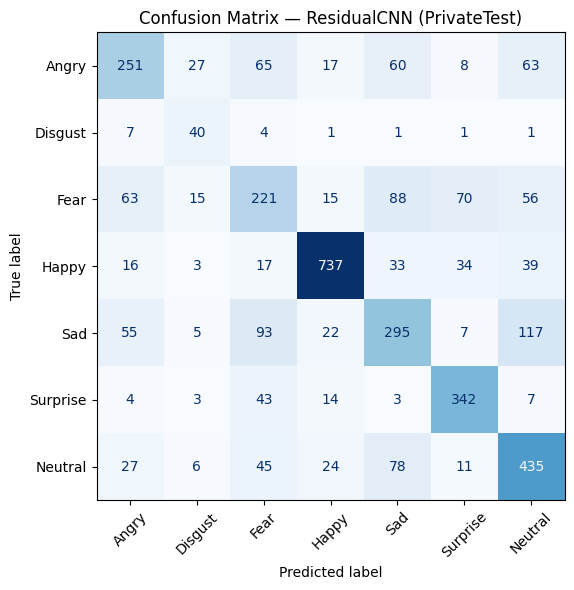

In [48]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Classification Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=list(emotion_labels.values())
))

cm   = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=list(emotion_labels.values())
)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — ResidualCNN (PrivateTest)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()